In [1]:
# -----------------------------------------------------------------------------
#  PART 1 -- Setup & load assets
# -----------------------------------------------------------------------------
import ee
import pandas as pd
 
ee.Authenticate()
ee.Initialize(project='osmgee')
 
watersheds = ee.FeatureCollection('projects/osmgee/assets/OSM_Watersheds')
watershed_geom = watersheds.geometry()
 
ASSET_PROJECT = 'projects/annual-ccdc-new/assets'
 
# Five-yearly years, matching the JS export pipeline (1985, 1990, ..., 2025)
FIVE_YEAR_YEARS = list(range(1985, 2026, 5))
print('Years to load:', FIVE_YEAR_YEARS)
 
# The 5 FTV-fitted bands actually exported per year. NOTE: NIR is NOT
# among these — NIR drove LandTrendr segmentation (band 1 in the JS
# pipeline), so its fitted values live inside the main 'LandTrendr'
# array, not as a separate '_fit' band, and were not included in the
# per-year exports (LT_fitted_1985, LT_fitted_1990, ... only contain
# Blue, Green, Red, SWIR1, SWIR2).
LT_FEATURES = ['Blue', 'Green', 'Red', 'SWIR1', 'SWIR2']

Years to load: [1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020, 2025]


In [2]:
# -----------------------------------------------------------------------------
#  Verify all 9 exported assets exist before using them
# -----------------------------------------------------------------------------
existing_assets = ee.data.listAssets({'parent': ASSET_PROJECT})
existing_ids = set(a['id'] for a in existing_assets.get('assets', []))
 
missing_years = []
found_years = []
for year in FIVE_YEAR_YEARS:
    expected_id = f'{ASSET_PROJECT}/LT_fitted_{year}'
    if expected_id in existing_ids:
        found_years.append(year)
    else:
        missing_years.append(year)
 
print(f'Found: {len(found_years)} / {len(FIVE_YEAR_YEARS)} years')
if missing_years:
    print('Missing years (not yet exported from GEE):', missing_years)
else:
    print('All 9 years present.')

Found: 9 / 9 years
All 9 years present.


In [3]:
# -----------------------------------------------------------------------------
#  Import each individual year image, rename bands to clean names
#  (LT_Blue_1985 -> Blue, LT_Green_1985 -> Green, etc.), rebuild as
#  ee.ImageCollection, one image per year -- same pattern as the
#  reference script, adapted for per-year assets instead of one
#  combined stack.
# -----------------------------------------------------------------------------
def load_and_rename_year(year):
    asset_id = f'{ASSET_PROJECT}/LT_fitted_{year}'
    orig_bands = [f'LT_{f}_{year}' for f in LT_FEATURES]
    new_bands = LT_FEATURES
 
    img = (ee.Image(asset_id)
           .select(orig_bands, new_bands)
           .set('year', year)
           .set('system:time_start', ee.Date.fromYMD(year, 6, 1).millis()))
    return img
 
 
year_images = [load_and_rename_year(y) for y in found_years]
 
LT_COLLECTION = ee.ImageCollection.fromImages(year_images)
 
print('Collection size:', LT_COLLECTION.size().getInfo())
print('First image bands:', LT_COLLECTION.first().bandNames().getInfo())
print('Years in collection:', LT_COLLECTION.aggregate_array('year').getInfo())

Collection size: 9
First image bands: ['Blue', 'Green', 'Red', 'SWIR1', 'SWIR2']
Years in collection: [1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020, 2025]


In [4]:
# Index Calculation
def add_no_nir_indices(image):
    """
    Compute indices that do NOT require NIR:
      - NBR2: (SWIR1 - SWIR2) / (SWIR1 + SWIR2)
    """
    nbr2 = image.normalizedDifference(['SWIR1', 'SWIR2']).rename('NBR2')
 
    return image.addBands([nbr2])
 
 
LT_COLLECTION = LT_COLLECTION.map(add_no_nir_indices)
LT_FEATURES = LT_FEATURES + ['NBR2']
 
print('\nLT_COLLECTION is ready with bands:', LT_FEATURES)
print('NDVI/EVI/NDWI still deferred -- resolve the NIR question above when ready.')
 
# Sanity check
print('Updated first image bands:', LT_COLLECTION.first().bandNames().getInfo())


LT_COLLECTION is ready with bands: ['Blue', 'Green', 'Red', 'SWIR1', 'SWIR2', 'NBR2']
NDVI/EVI/NDWI still deferred -- resolve the NIR question above when ready.
Updated first image bands: ['Blue', 'Green', 'Red', 'SWIR1', 'SWIR2', 'NBR2']


Years: [1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020, 2025]
LandTrendr-fitted mean Red: [0.04071578567241401, 0.042256528557901935, 0.04369118217720751, 0.039381546398377404, 0.03864286557605697, 0.03851873852638421, 0.038932847008412486, 0.03836471479467623, 0.039154969457565955]


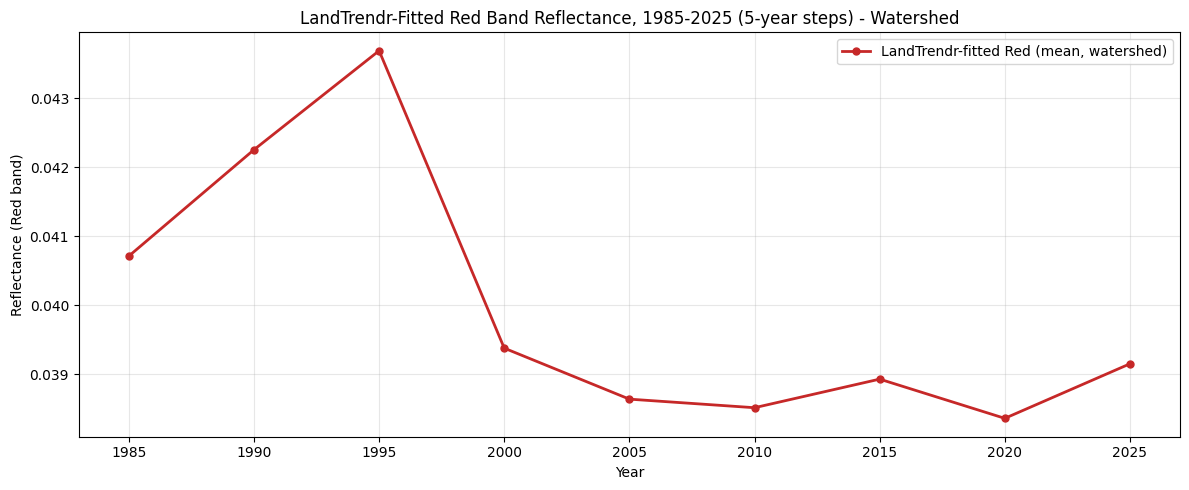

In [5]:
# -----------------------------------------------------------------------------
#  LandTrendr-fitted Red band time series -- spatial mean per year over
#  the watershed, same pattern used throughout the rest of this pipeline.
# -----------------------------------------------------------------------------
import matplotlib.pyplot as plt
 
def get_mean_red(image):
    mean_dict = image.select('Red').reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=watershed_geom,
        scale=30,
        maxPixels=1e9,
        bestEffort=True
    )
    return image.set('mean_red', mean_dict.get('Red'))
 
 
annual_red_mean = LT_COLLECTION.map(get_mean_red)
 
years_red_list = annual_red_mean.aggregate_array('year').getInfo()
mean_red_fitted = annual_red_mean.aggregate_array('mean_red').getInfo()
 
print('Years:', years_red_list)
print('LandTrendr-fitted mean Red:', mean_red_fitted)
 
plt.figure(figsize=(12, 5))
plt.plot(years_red_list, mean_red_fitted, marker='o', markersize=5,
         linewidth=2, color='#C62828', label='LandTrendr-fitted Red (mean, watershed)')
plt.xlabel('Year')
plt.ylabel('Reflectance (Red band)')
plt.title('LandTrendr-Fitted Red Band Reflectance, 1985-2025 (5-year steps) - Watershed')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/red_fitted_timeseries.png', dpi=150)
plt.show()

GIF URL: https://earthengine.googleapis.com/v1/projects/osmgee/videoThumbnails/912fec75d681cee680bb3d12b84fb147-6f78232cf34d199d16998aa6585b55de:getPixels


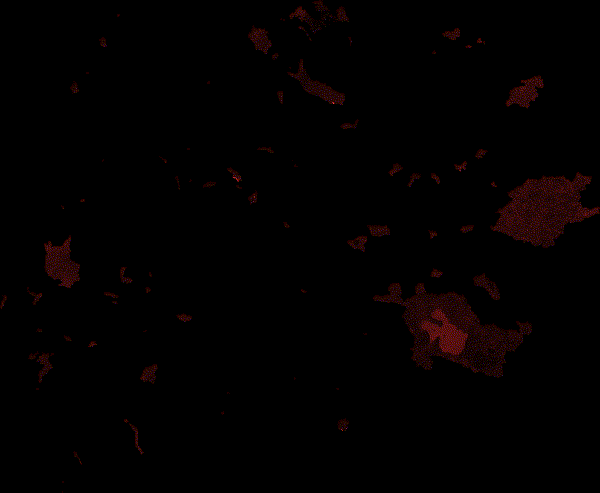

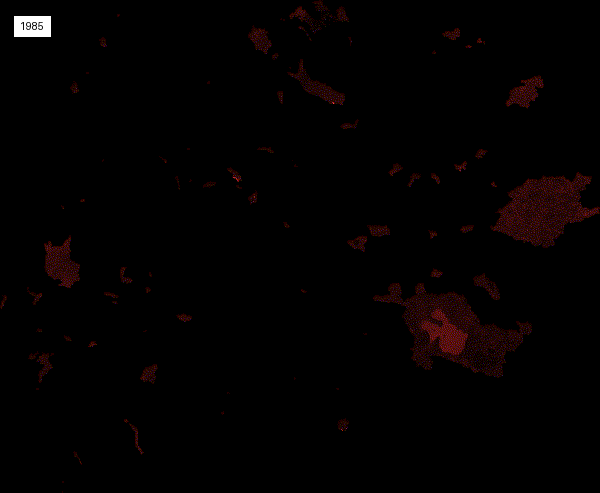

In [6]:
# -----------------------------------------------------------------------------
#  Build a time-series GIF of LandTrendr-fitted Red band
# -----------------------------------------------------------------------------
import requests
from IPython.display import Image, display
 
red_col = LT_COLLECTION.select('Red').map(
    lambda img: img.clip(watersheds)
)
 
# Red reflectance vis params -- adjust min/max if the GIF looks too
# washed out or too dark once you see it (0.0-0.3 is a reasonable
# starting range for Landsat surface reflectance, same as the
# true-colour vis used earlier in the pipeline)
vis_params_red = {
    'min':          0.0,
    'max':          0.3,
    'palette':      ['000000', '3d0d0d', '8b1a1a', 'e63232', 'ff8080', 'ffffff'],
    'region':       watershed_geom,
    'dimensions':   600,
    'framesPerSecond': 2,   # slower than the reference (3fps) -- only 9 frames total
    'crs':          'EPSG:32612'  # matches the CCDC pipeline's CRS; adjust if needed
}
 
gif_url_red = red_col.getVideoThumbURL(vis_params_red)
print('GIF URL:', gif_url_red)
 
# Download and display
gif_path_red = '/content/red_timeseries.gif'
r = requests.get(gif_url_red)
with open(gif_path_red, 'wb') as f:
    f.write(r.content)
display(Image(gif_path_red))
 
# -----------------------------------------------------------------------------
#  Add year labels burned into each frame
# -----------------------------------------------------------------------------
from PIL import Image as PILImage, ImageDraw, ImageFont
 
try:
    font = ImageFont.truetype(
        '/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf', 32)
except OSError:
    font = ImageFont.load_default()
 
gif_red = PILImage.open(gif_path_red)
frames_red = []
try:
    while True:
        frame = gif_red.copy().convert('RGB')
        draw = ImageDraw.Draw(frame)
        year = found_years[gif_red.tell()]
        label = str(year)
 
        x, y = 20, 20
        bbox = draw.textbbox((x, y), label, font=font)
        pad = 6
        draw.rectangle(
            [bbox[0] - pad, bbox[1] - pad, bbox[2] + pad, bbox[3] + pad],
            fill='white'
        )
        draw.text((x, y), label, fill='black', font=font)
        frames_red.append(frame)
        gif_red.seek(gif_red.tell() + 1)
except EOFError:
    pass
 
out_gif_red = '/content/red_timeseries_labeled.gif'
frames_red[0].save(out_gif_red, save_all=True, append_images=frames_red[1:],
                    duration=500, loop=0)  # 500ms/frame -- slower, only 9 frames
 
display(Image(out_gif_red))

In [6]:
# ============================================
# Load the ABMI photoplot / Wetland Inventory training layer
# ============================================

training_source = ee.FeatureCollection('projects/annual-ccdc-new/assets/PhotoPlotsClippedtoWatershed_OSM')

print('Feature count:', training_source.size().getInfo())
print('First feature:', training_source.first().getInfo())

# Confirm the MyClass field made it through the upload correctly
print('MyClass values present:', training_source.aggregate_array('MyClass').distinct().getInfo())

Feature count: 442
First feature: {'type': 'Feature', 'geometry': {'type': 'Polygon', 'coordinates': [[[-111.37442014879714, 57.351462277227704], [-111.37439685240678, 57.35144823345668], [-111.37386185732595, 57.351093505202236], [-111.37355585760636, 57.35084807360108], [-111.37350727740403, 57.35083771045387], [-111.37346738961708, 57.350823178253286], [-111.37324730249911, 57.35137936349455], [-111.37323245669401, 57.351445877548734], [-111.37321767841289, 57.35151247010698], [-111.37321145745604, 57.35157473674787], [-111.37322705555799, 57.351584177917196], [-111.37325174215479, 57.351584855928614], [-111.37354481352484, 57.351629020900084], [-111.37391574286411, 57.351720052622014], [-111.37419665752107, 57.35171924006324], [-111.37451921821828, 57.3516303191128], [-111.37442014879714, 57.351462277227704]]]}, 'id': '0000000000000000007f', 'properties': {'ABMI_SITE': 388, 'AREA_NET': 0, 'DENSITY': 'C', 'GAWL_TY': 'BTNN', 'HEIGHT': 0, 'HYDR_REG': 'STA', 'INFRA_CL': '', 'INFRA_TY':

In [7]:
# ============================================
# Check the actual size distribution of training polygons, by class
# ============================================

areas_and_classes = training_source.reduceColumns(
    reducer=ee.Reducer.toList(2),
    selectors=['Shape_Area', 'MyClass']
).get('list').getInfo()

import pandas as pd

df_areas = pd.DataFrame(areas_and_classes, columns=['Shape_Area', 'MyClass'])

print(df_areas.groupby('MyClass')['Shape_Area'].describe())

            count          mean           std          min           25%  \
MyClass                                                                    
Vegetation  437.0  9.595662e+04  1.742204e+05   166.111626  19871.676849   
Water         5.0  4.217620e+06  9.395710e+06  6137.805815  11245.566385   

                     50%           75%           max  
MyClass                                               
Vegetation  45760.164483  99434.896932  2.109552e+06  
Water       18768.138358  26777.591665  2.102517e+07  


In [8]:
# ============================================
# Generate points on a 100m grid within each training polygon (cleaned)
# ============================================

GRID_SPACING_M = 100

def grid_points_for_polygon(feature):
    geom = feature.geometry()

    # A fixed-scale coordinate image, sampled within the polygon,
    # produces a regular grid of points at the given spacing
    grid_image = ee.Image.pixelCoordinates(ee.Projection('EPSG:32612').atScale(GRID_SPACING_M))

    grid_fc = grid_image.sample(
        region=geom,
        scale=GRID_SPACING_M,
        geometries=True
    )

    grid_fc = grid_fc.map(lambda pt: pt.set({
        'MyClass': feature.get('MyClass'),
        'POLYGON_ID': feature.get('POLYGON_ID')
    }))

    return grid_fc


training_points = training_source.map(grid_points_for_polygon).flatten()

print('Total sample points generated:', training_points.size().getInfo())
print('Class distribution:', training_points.aggregate_histogram('MyClass').getInfo())

Total sample points generated: 6305
Class distribution: {'Vegetation': 4194, 'Water': 2111}


In [9]:
# ============================================
# Spatially thin points — enforce a minimum distance between kept points
# ============================================

MIN_DISTANCE_M = 300  # adjust based on how aggressive you want thinning to be

def thin_points_by_distance(points_fc, min_distance):
    """
    Iteratively keep points, removing any subsequent point that falls
    within min_distance of an already-kept point. This reduces spatial
    autocorrelation between training samples.
    """
    # Add a random column to shuffle iteration order, so thinning isn't
    # biased toward whichever point happened to come first in the collection
    points_with_random = points_fc.randomColumn('rand', seed=42)
    sorted_points = points_with_random.sort('rand')

    # ee.Geometry.MultiPoint accumulation approach: iterate through points,
    # keep only those farther than min_distance from all previously-kept points
    def thin_iteration(current, previous):
        current = ee.Feature(current)
        previous = ee.List(previous)

        kept_geoms = ee.FeatureCollection(previous).geometry()
        # If no points kept yet, keep this one automatically
        is_far_enough = ee.Algorithms.If(
            ee.FeatureCollection(previous).size().eq(0),
            True,
            current.geometry().distance(kept_geoms, min_distance).gt(min_distance)
        )

        return ee.Algorithms.If(is_far_enough, previous.add(current), previous)

    thinned_list = sorted_points.toList(sorted_points.size()).iterate(thin_iteration, ee.List([]))

    return ee.FeatureCollection(ee.List(thinned_list))


# Apply separately per class, so thinning doesn't let one class's density
# drown out the other's during the shared iteration
water_points = training_points.filter(ee.Filter.eq('MyClass', 'Water'))
veg_points = training_points.filter(ee.Filter.eq('MyClass', 'Vegetation'))

water_thinned = thin_points_by_distance(water_points, MIN_DISTANCE_M)
veg_thinned = thin_points_by_distance(veg_points, MIN_DISTANCE_M)

training_points_thinned = water_thinned.merge(veg_thinned)

print('Water points before/after thinning:', water_points.size().getInfo(), '/', water_thinned.size().getInfo())
print('Veg points before/after thinning:', veg_points.size().getInfo(), '/', veg_thinned.size().getInfo())

Water points before/after thinning: 2111 / 175
Veg points before/after thinning: 4194 / 368


In [10]:
# ============================================
# Sample LT_COLLECTION (clean bands + NBR2) at training points
# ============================================

TRAINING_YEAR = 1985

# Filter LT_COLLECTION down to just the training year's image
fitted_image = LT_COLLECTION.filter(ee.Filter.eq('year', TRAINING_YEAR)).first()

print('Bands available:', fitted_image.bandNames().getInfo())

# Merge the thinned Water and Vegetation points (if not already combined)
training_points_thinned = water_thinned.merge(veg_thinned)

# Sample the fitted image at each point location
sampled_training_data = fitted_image.sampleRegions(
    collection=training_points_thinned,
    scale=30,
    tileScale=8,
    geometries=True
)

print('Sampled feature count:', sampled_training_data.size().getInfo())
print('First sampled feature:', sampled_training_data.first().getInfo())

Bands available: ['Blue', 'Green', 'Red', 'SWIR1', 'SWIR2', 'NBR2']
Sampled feature count: 508


First sampled feature: {'type': 'Feature', 'geometry': {'geodesic': False, 'type': 'Point', 'coordinates': [-110.45661999413265, 56.50612940650636]}, 'id': '1_0000000000000000012f_2058_0', 'properties': {'Blue': 0.06879905611276627, 'Green': 0.10884027928113937, 'MyClass': 'Water', 'NBR2': 0.00843804981559515, 'POLYGON_ID': 5130067, 'Red': 0.08900116384029388, 'SWIR1': 0.005185444373637438, 'SWIR2': 0.005098666530102491, 'rand': 0.0009142173531471176, 'x': 5334.5, 'y': 62625.5}}


In [11]:
# ============================================
# Pull sampled training data into pandas
# ============================================

import pandas as pd

sampled_list = sampled_training_data.getInfo()['features']

rows = []
for f in sampled_list:
    props = f['properties']
    rows.append(props)

df = pd.DataFrame(rows)

print(df.shape)
print(df.head())
print(df['MyClass'].value_counts())

(508, 11)
       Blue     Green MyClass      NBR2  POLYGON_ID       Red     SWIR1  \
0  0.068799  0.108840   Water  0.008438     5130067  0.089001  0.005185   
1  0.044978  0.106217   Water -0.362998     5130067  0.082265  0.003947   
2  0.055971  0.107983   Water  0.284423     5130067  0.088710  0.004260   
3  0.066270  0.103930   Water  0.175911     5130067  0.083092  0.004637   
4  0.043058  0.090246   Water  0.050024     5130067  0.077315  0.005151   

      SWIR2      rand       x        y  
0  0.005099  0.000914  5334.5  62625.5  
1  0.008445  0.001913  5351.5  62605.5  
2  0.002373  0.002430  5355.5  62608.5  
3  0.003249  0.003020  5342.5  62609.5  
4  0.004660  0.003680  5368.5  62586.5  
MyClass
Vegetation    365
Water         143
Name: count, dtype: int64


In [12]:
# ============================================
# Encode MyClass as numeric (required by smileRandomForest)
# ============================================

def encode_class(feature):
    my_class = feature.get('MyClass')
    class_num = ee.Algorithms.If(
        ee.String(my_class).equals('Water'), 0,
        ee.Algorithms.If(ee.String(my_class).equals('Vegetation'), 1, -1)
    )
    return feature.set('MyClass_num', class_num)

sampled_training_data_encoded = sampled_training_data.map(encode_class)

print('Encoded class distribution:', sampled_training_data_encoded.aggregate_histogram('MyClass_num').getInfo())

Encoded class distribution: {'0': 143, '1': 365}


In [13]:
# ============================================
# Train ee.Classifier Random Forest
# ============================================

FEATURE_BANDS = ['Blue', 'Green', 'Red', 'SWIR1', 'SWIR2', 'NBR2']

ee_classifier = ee.Classifier.smileRandomForest(numberOfTrees=100).train(
    features=sampled_training_data_encoded,
    classProperty='MyClass_num',
    inputProperties=FEATURE_BANDS
)

print('GEE classifier trained.')

GEE classifier trained.


In [14]:
# ============================================
# Feature importance from the trained GEE classifier
# ============================================

classifier_info = ee_classifier.explain()
print('Classifier info:', classifier_info.getInfo())

Classifier info: {'classes': [0, 1], 'importance': {'Blue': 3.5148835482083705, 'Green': 13.01063424068593, 'NBR2': 5.51099797625848, 'Red': 8.952328179097828, 'SWIR1': 17.19790754631386, 'SWIR2': 17.12758809348561}, 'numberOfTrees': 100, 'outOfBagErrorEstimate': 0.007874015748031496, 'trees': ['n= 255\nnode), split, n, loss, yval, (yprob)\n* denotes terminal node\n1) root 255 103.34 1 (0.28405 0.71595)\n 2) SWIR1<=0.0299591 71 0.0000 0 (0.98630 0.013699) *\n 3) SWIR1>0.0299591 184 1.9891 1 (0.010753 0.98925)\n  6) Blue<=0.0328923 144 0.0000 1 (0.0068493 0.99315) *\n  7) Blue>0.0328923 40 1.9500 1 (0.047619 0.95238)\n   14) Blue<=0.0332223 1 0.0000 0 (0.66667 0.33333) *\n   15) Blue>0.0332223 39 0.0000 1 (0.024390 0.97561) *\n', 'n= 255\nnode), split, n, loss, yval, (yprob)\n* denotes terminal node\n1) root 255 103.34 1 (0.28405 0.71595)\n 2) SWIR2<=0.0186248 72 0.0000 0 (0.98649 0.013514) *\n 3) SWIR2>0.0186248 183 0.0000 1 (0.0054054 0.99459) *\n', 'n= 255\nnode), split, n, loss, yva

In [15]:
# ============================================
# Classify the composite directly — no export/download needed
# ============================================

fitted_image_bands = fitted_image.select(FEATURE_BANDS)

classified_image = fitted_image_bands.classify(ee_classifier)

print('Classified image bands:', classified_image.bandNames().getInfo())

Classified image bands: ['classification']


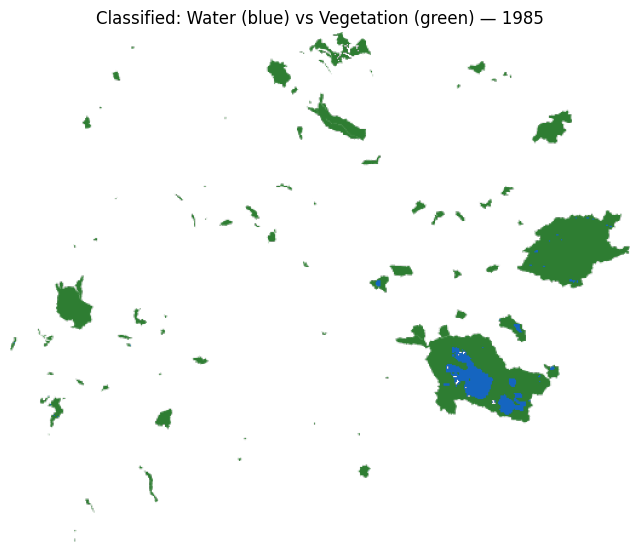

In [16]:
# ============================================
# Visualize the classified result
# ============================================

class_vis = {
    'min': 0,
    'max': 1,
    'palette': ['1565C0', '2E7D32']  # blue = Water, green = Vegetation
}

thumb_url = classified_image.clip(watershed_geom).getThumbURL({
    'min': 0, 'max': 1,
    'palette': ['1565C0', '2E7D32'],
    'dimensions': 512,
    'region': watershed_geom,
})

import requests
from PIL import Image
from io import BytesIO

response = requests.get(thumb_url)
img = Image.open(BytesIO(response.content))

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis('off')
plt.title(f'Classified: Water (blue) vs Vegetation (green) — {TRAINING_YEAR}')
plt.show()

In [111]:
# ============================================
# Export the classified raster to Asset, for later use
# ============================================

export_task = ee.batch.Export.image.toAsset(
    image=classified_image.clip(watershed_geom),
    description=f'classified_{TRAINING_YEAR}',
    assetId=f'{ASSET_PROJECT}/classified_{TRAINING_YEAR}',
    region=watershed_geom,
    scale=30,
    crs='EPSG:32612',
    maxPixels=1e13
)

export_task.start()
print('Export started. Task ID:', export_task.id)

Export started. Task ID: NNL26BBPDTS72IW46R3KFEEP


In [19]:
# ============================================
# Export all 9 classified years to Drive
# ============================================

ALL_CLASSIFIED_YEARS = list(range(1985, 2026, 5))  # 1985, 1990, ..., 2025

export_tasks = []

for year in ALL_CLASSIFIED_YEARS:
    classified_img = ee.Image(f'{ASSET_PROJECT}/classified_{year}')

    task = ee.batch.Export.image.toDrive(
        image=classified_img,
        description=f'classified_{year}_export',
        folder='GEE_exports',
        fileNamePrefix=f'classified_{year}',
        region=watershed_geom,
        scale=30,
        crs='EPSG:32612',
        maxPixels=1e13,
        fileFormat='GeoTIFF'
    )
    task.start()
    export_tasks.append((year, task))
    print(f'{year}: export started, task ID: {task.id}')

1985: export started, task ID: XRHEB3L4D4EZPKLXDUGIDDJR
1990: export started, task ID: 7NCMNRAWY3PLLXV5IKRB5CEF
1995: export started, task ID: XJDIXXRQNXOZXJEDUQ72FEPU
2000: export started, task ID: TCXTWRZKBB3FF4C675WBWYPM
2005: export started, task ID: OVVVW6VVXOZGON363MAQGJGK
2010: export started, task ID: XMAN6CNKXULCHA6T5KKSV4XK
2015: export started, task ID: VIDL3AJQ3QFJXHPS4CDYZTR7
2020: export started, task ID: DDRDR6WFKQ5LKWZR66LAPPPC
2025: export started, task ID: FIR3HENTCBZGTKWNIEIATPIW


In [20]:
for year, task in export_tasks:
    print(f'{year}: {task.status()["state"]}')

1985: READY
1990: READY
1995: READY
2000: READY
2005: READY
2010: READY
2015: READY
2020: READY
2025: READY


In [14]:
# ============================================
# Load all 9 classified rasters from Drive
# ============================================

from google.colab import drive
drive.mount('/content/drive')

import rasterio
import numpy as np

ALL_YEARS = list(range(1985, 2026, 5))
PIXEL_AREA_HA = (30 * 30) / 10000

class_arrays = {}

for year in ALL_YEARS:
    path = f'/content/drive/MyDrive/GEE_Exports/classified_{year}.tif'
    with rasterio.open(path) as src:
        arr = src.read(1)  # single band: 0=Water, 1=Vegetation
        class_arrays[year] = arr

print('Loaded years:', list(class_arrays.keys()))
print('Raster shape (should match across years):', class_arrays[ALL_YEARS[0]].shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded years: [1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020, 2025]
Raster shape (should match across years): (5302, 6457)


In [15]:
# ============================================
# Per-year class totals (hectares)
# ============================================

CLASS_NAMES = {0: 'Water', 1: 'Vegetation'}
n_classes = 2

totals = np.zeros((len(ALL_YEARS), n_classes))

for i, year in enumerate(ALL_YEARS):
    arr = class_arrays[year]
    for c in range(n_classes):
        totals[i, c] = np.sum(arr == c) * PIXEL_AREA_HA

print('Totals (rows=years, cols=[Water, Vegetation]):')
print(totals)

# ============================================
# Transition matrices between consecutive years
# ============================================

transitions = []
for i in range(len(ALL_YEARS) - 1):
    arr_a = class_arrays[ALL_YEARS[i]]
    arr_b = class_arrays[ALL_YEARS[i + 1]]

    T = np.zeros((n_classes, n_classes))
    for c_from in range(n_classes):
        for c_to in range(n_classes):
            T[c_from, c_to] = np.sum((arr_a == c_from) & (arr_b == c_to)) * PIXEL_AREA_HA
    transitions.append(T)

print('Number of transition matrices:', len(transitions))

Totals (rows=years, cols=[Water, Vegetation]):
[[2916050.76  165100.5 ]
 [2914537.68  166613.58]
 [2914190.28  166960.98]
 [2914430.31  166720.95]
 [2913764.58  167386.68]
 [2914052.94  167098.32]
 [2913482.88  167668.38]
 [2913614.01  167537.25]
 [2913771.87  167379.39]]
Number of transition matrices: 8


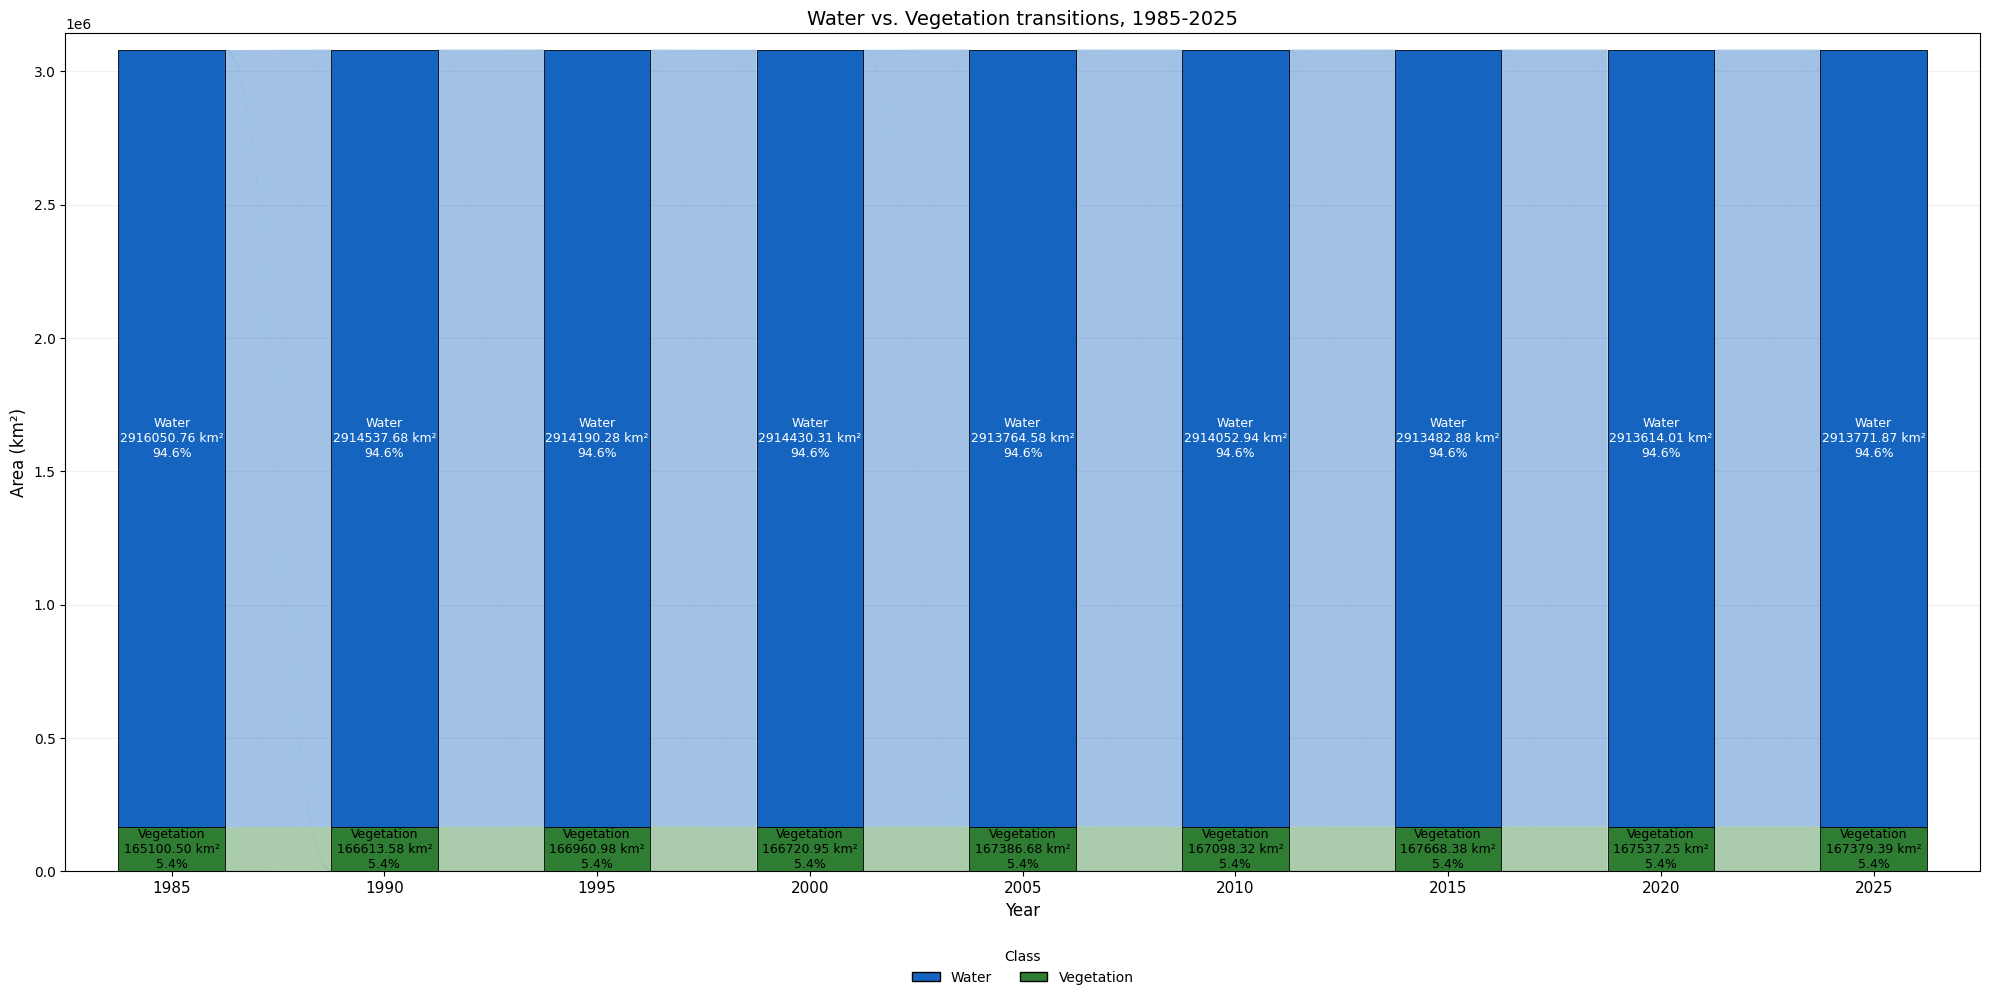

In [18]:
# ============================================
# Alluvial diagram — stacked bars with flows, in km²
# ============================================

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.path import Path
import matplotlib.patches as mpatches

class_colors = ['#1565C0', '#2E7D32']  # 0=Water (blue), 1=Vegetation (green)

fig, ax = plt.subplots(figsize=(20, 10))
bar_width = 0.5
x_positions = np.arange(len(ALL_YEARS))

stack_order = [1, 0]
stratum_bounds = {}

for i, xc in enumerate(x_positions):
    y_cursor = 0.0
    for c in stack_order:
        h = totals[i, c]
        if h > 0:
            ax.add_patch(Rectangle(
                (xc - bar_width / 2, y_cursor), bar_width, h,
                facecolor=class_colors[c], edgecolor='black', linewidth=0.6, zorder=3
            ))
            pct = 100 * h / totals[i].sum()
            text_color = 'white' if c == 0 else 'black'
            ax.text(xc, y_cursor + h / 2,
                    f'{CLASS_NAMES[c]}\n{h:.2f} km\u00b2\n{pct:.1f}%',
                    ha='center', va='center', fontsize=9, color=text_color, zorder=4)
            stratum_bounds[(i, c)] = (y_cursor, y_cursor + h)
        else:
            stratum_bounds[(i, c)] = (y_cursor, y_cursor)
        y_cursor += h

for i, T in enumerate(transitions):
    x_a = x_positions[i] + bar_width / 2
    x_b = x_positions[i + 1] - bar_width / 2
    src_cursor = {c: stratum_bounds[(i, c)][0] for c in range(n_classes)}
    tgt_cursor = {c: stratum_bounds[(i + 1, c)][0] for c in range(n_classes)}

    for c_from in stack_order[::-1]:
        for c_to in stack_order[::-1]:
            h = T[c_from, c_to]
            if h <= 0:
                continue
            y0_a = src_cursor[c_from]; y1_a = y0_a + h; src_cursor[c_from] = y1_a
            y0_b = tgt_cursor[c_to]; y1_b = y0_b + h; tgt_cursor[c_to] = y1_b
            xm = (x_a + x_b) / 2
            verts = [(x_a, y0_a), (xm, y0_a), (xm, y0_b), (x_b, y0_b),
                     (x_b, y1_b), (xm, y1_b), (xm, y1_a), (x_a, y1_a), (x_a, y0_a)]
            codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4,
                     Path.LINETO, Path.CURVE4, Path.CURVE4, Path.CURVE4, Path.CLOSEPOLY]
            ax.add_patch(mpatches.PathPatch(Path(verts, codes),
                         facecolor=class_colors[c_from], edgecolor='none', alpha=0.4, zorder=2))

ax.set_xticks(x_positions)
ax.set_xticklabels(ALL_YEARS, fontsize=11)
ax.set_ylabel('Area (km\u00b2)', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.set_title(f'Water vs. Vegetation transitions, {ALL_YEARS[0]}-{ALL_YEARS[-1]}', fontsize=14)
ax.set_ylim(0, totals.sum(axis=1).max() * 1.02)
ax.set_xlim(x_positions[0] - 0.5, x_positions[-1] + 0.5)
ax.grid(axis='y', alpha=0.2, zorder=1)
ax.set_axisbelow(True)

legend_patches = [mpatches.Patch(facecolor=class_colors[c], edgecolor='black', label=CLASS_NAMES[c])
                   for c in range(n_classes)]
ax.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, -0.15),
          ncol=n_classes, frameon=False, title='Class')

plt.tight_layout()
plt.savefig('/content/water_vegetation_alluvial_km2.png', dpi=200, bbox_inches='tight')
plt.show()

In [20]:
# ============================================
# Diagnose the NoData value, then exclude it from counts
# ============================================

with rasterio.open('/content/drive/MyDrive/GEE_Exports/classified_1985.tif') as src:
    print('NoData value:', src.nodata)
    print('Data type:', src.dtypes)

arr = class_arrays[1985]
print('Unique values and counts:', np.unique(arr, return_counts=True))

NoData value: None
Data type: ('int32',)
Unique values and counts: (array([0, 1], dtype=int32), array([32400564,  1834450]))


In [23]:
PIXEL_AREA_KM2 = (30 * 30) / 1_000_000  # 30m pixels, in km²

In [27]:
# ============================================
# Recompute totals, properly excluding NoData pixels
# ============================================

PIXEL_AREA_KM2 = (30 * 30) / 1_000_000  # 30m pixels, in km²

NODATA_VALUE = None  # fill in based on the diagnostic check

totals = np.zeros((len(ALL_YEARS), n_classes))

for i, year in enumerate(ALL_YEARS):
    arr = class_arrays[year]
    valid_mask = arr != NODATA_VALUE if NODATA_VALUE is not None else np.ones_like(arr, dtype=bool)

    for c in range(n_classes):
        totals[i, c] = np.sum((arr == c) & valid_mask) * PIXEL_AREA_KM2

print(totals)

[[29160.5076  1651.005 ]
 [29145.3768  1666.1358]
 [29141.9028  1669.6098]
 [29144.3031  1667.2095]
 [29137.6458  1673.8668]
 [29140.5294  1670.9832]
 [29134.8288  1676.6838]
 [29136.1401  1675.3725]
 [29137.7187  1673.7939]]


In [29]:
with rasterio.open('/content/drive/MyDrive/GEE_Exports/classified_1985.tif') as src:
    print('NoData value:', src.nodata)

arr = class_arrays[1985]
print('Unique values and counts:', np.unique(arr, return_counts=True))

NoData value: None
Unique values and counts: (array([0, 1], dtype=int32), array([32400564,  1834450]))


In [31]:
# ============================================
# Build a watershed boundary mask, matching the raster's grid exactly
# ============================================

from rasterio.features import geometry_mask
import geopandas as gpd

# Get the watershed geometry as GeoJSON (already have this as watershed_geom in GEE)
watershed_geojson = watershed_geom.getInfo()

with rasterio.open('/content/drive/MyDrive/GEE_Exports/classified_1985.tif') as src:
    transform = src.transform
    out_shape = (src.height, src.width)

    # geometry_mask returns True OUTSIDE the geometry by default;
    # invert=True flips it so True = INSIDE the watershed
    watershed_mask = geometry_mask(
        [watershed_geojson],
        out_shape=out_shape,
        transform=transform,
        invert=True
    )

print('Watershed mask shape:', watershed_mask.shape)
print('Valid (inside watershed) pixels:', watershed_mask.sum())
print('Total raster pixels:', watershed_mask.size)

Watershed mask shape: (5302, 6457)
Valid (inside watershed) pixels: 0
Total raster pixels: 34235014


In [32]:
PIXEL_AREA_KM2 = (30 * 30) / 1_000_000

totals = np.zeros((len(ALL_YEARS), n_classes))

for i, year in enumerate(ALL_YEARS):
    arr = class_arrays[year]
    for c in range(n_classes):
        totals[i, c] = np.sum((arr == c) & watershed_mask) * PIXEL_AREA_KM2

print(totals)

[[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]


In [34]:
# ============================================
# Reproject watershed geometry to match raster CRS (EPSG:32612), then mask
# ============================================

watershed_utm = watershed_geom.transform('EPSG:32612', maxError=1)
watershed_utm_geojson = watershed_utm.getInfo()

with rasterio.open('/content/drive/MyDrive/GEE_Exports/classified_1985.tif') as src:
    transform = src.transform
    out_shape = (src.height, src.width)

    watershed_mask = geometry_mask(
        [watershed_utm_geojson],
        out_shape=out_shape,
        transform=transform,
        invert=True
    )

print('Valid (inside watershed) pixels:', watershed_mask.sum())
print('Total raster pixels:', watershed_mask.size)

Valid (inside watershed) pixels: 1958621
Total raster pixels: 34235014


In [36]:
with rasterio.open('/content/drive/MyDrive/GEE_Exports/classified_1985.tif') as src:
    print('Pixel size (x, y):', src.res)

Pixel size (x, y): (30.0, 30.0)


In [38]:
# ============================================
# Cross-check: watershed area from GEE geometry vs. from the mask
# ============================================

watershed_area_km2_gee = ee.Number(watershed_geom.area(maxError=1)).divide(1e6).getInfo()
print('Watershed area from GEE geometry:', watershed_area_km2_gee, 'km²')

with rasterio.open('/content/drive/MyDrive/GEE_Exports/classified_1985.tif') as src:
    pixel_area_km2 = (src.res[0] * src.res[1]) / 1_000_000

mask_area_km2 = watershed_mask.sum() * pixel_area_km2
print('Watershed area from mask:', mask_area_km2, 'km²')

Watershed area from GEE geometry: 1897.4343255869812 km²
Watershed area from mask: 1762.7589 km²


In [39]:
# ============================================
# Recompute totals using the corrected, CRS-matched watershed mask
# ============================================

PIXEL_AREA_KM2 = (src.res[0] * src.res[1]) / 1_000_000  # use actual pixel size, not assumed 30m

totals = np.zeros((len(ALL_YEARS), n_classes))

for i, year in enumerate(ALL_YEARS):
    arr = class_arrays[year]
    for c in range(n_classes):
        totals[i, c] = np.sum((arr == c) & watershed_mask) * PIXEL_AREA_KM2

print(totals)

# ============================================
# Recompute transitions with the same mask
# ============================================

transitions = []
for i in range(len(ALL_YEARS) - 1):
    arr_a = class_arrays[ALL_YEARS[i]]
    arr_b = class_arrays[ALL_YEARS[i + 1]]

    T = np.zeros((n_classes, n_classes))
    for c_from in range(n_classes):
        for c_to in range(n_classes):
            T[c_from, c_to] = np.sum((arr_a == c_from) & (arr_b == c_to) & watershed_mask) * PIXEL_AREA_KM2
    transitions.append(T)

print('Transitions computed for', len(transitions), 'year-pairs')

[[ 191.7576 1571.0013]
 [ 176.8977 1585.8612]
 [ 173.5839 1589.175 ]
 [ 175.3236 1587.4353]
 [ 169.3944 1593.3645]
 [ 172.2078 1590.5511]
 [ 166.6278 1596.1311]
 [ 167.9382 1594.8207]
 [ 169.4529 1593.306 ]]
Transitions computed for 8 year-pairs


In [41]:
for year in ALL_YEARS:
    with rasterio.open(f'/content/drive/MyDrive/GEE_Exports/classified_{year}.tif') as src:
        print(year, src.shape, src.transform)

1985 (5302, 6457) | 30.00, 0.00, 390420.00|
| 0.00,-30.00, 6369810.00|
| 0.00, 0.00, 1.00|
1990 (5302, 6457) | 30.00, 0.00, 390420.00|
| 0.00,-30.00, 6369810.00|
| 0.00, 0.00, 1.00|
1995 (5302, 6457) | 30.00, 0.00, 390420.00|
| 0.00,-30.00, 6369810.00|
| 0.00, 0.00, 1.00|
2000 (5302, 6457) | 30.00, 0.00, 390420.00|
| 0.00,-30.00, 6369810.00|
| 0.00, 0.00, 1.00|
2005 (5302, 6457) | 30.00, 0.00, 390420.00|
| 0.00,-30.00, 6369810.00|
| 0.00, 0.00, 1.00|
2010 (5302, 6457) | 30.00, 0.00, 390420.00|
| 0.00,-30.00, 6369810.00|
| 0.00, 0.00, 1.00|
2015 (5302, 6457) | 30.00, 0.00, 390420.00|
| 0.00,-30.00, 6369810.00|
| 0.00, 0.00, 1.00|
2020 (5302, 6457) | 30.00, 0.00, 390420.00|
| 0.00,-30.00, 6369810.00|
| 0.00, 0.00, 1.00|
2025 (5302, 6457) | 30.00, 0.00, 390420.00|
| 0.00,-30.00, 6369810.00|
| 0.00, 0.00, 1.00|


In [42]:
# ============================================
# Recompute totals and transitions using the CRS-matched watershed mask
# ============================================

PIXEL_AREA_KM2 = (src.res[0] * src.res[1]) / 1_000_000

CLASS_NAMES = {0: 'Water', 1: 'Vegetation'}
n_classes = 2

# --- Totals per year ---
totals = np.zeros((len(ALL_YEARS), n_classes))

for i, year in enumerate(ALL_YEARS):
    arr = class_arrays[year]
    for c in range(n_classes):
        totals[i, c] = np.sum((arr == c) & watershed_mask) * PIXEL_AREA_KM2

print('Totals per year (rows=years, cols=[Water, Vegetation]):')
print(totals)

# --- Transitions between consecutive years ---
transitions = []
for i in range(len(ALL_YEARS) - 1):
    arr_a = class_arrays[ALL_YEARS[i]]
    arr_b = class_arrays[ALL_YEARS[i + 1]]

    T = np.zeros((n_classes, n_classes))
    for c_from in range(n_classes):
        for c_to in range(n_classes):
            T[c_from, c_to] = np.sum((arr_a == c_from) & (arr_b == c_to) & watershed_mask) * PIXEL_AREA_KM2
    transitions.append(T)

print('\nTransitions computed for', len(transitions), 'year-pairs')

Totals per year (rows=years, cols=[Water, Vegetation]):
[[ 191.7576 1571.0013]
 [ 176.8977 1585.8612]
 [ 173.5839 1589.175 ]
 [ 175.3236 1587.4353]
 [ 169.3944 1593.3645]
 [ 172.2078 1590.5511]
 [ 166.6278 1596.1311]
 [ 167.9382 1594.8207]
 [ 169.4529 1593.306 ]]

Transitions computed for 8 year-pairs


In [43]:
# ============================================
# Sanity check: does total area per year look stable and plausible?
# ============================================

for i, year in enumerate(ALL_YEARS):
    year_total = totals[i].sum()
    water_pct = 100 * totals[i, 0] / year_total
    veg_pct = 100 * totals[i, 1] / year_total
    print(f'{year}: total={year_total:.1f} km², Water={water_pct:.1f}%, Vegetation={veg_pct:.1f}%')

1985: total=1762.8 km², Water=10.9%, Vegetation=89.1%
1990: total=1762.8 km², Water=10.0%, Vegetation=90.0%
1995: total=1762.8 km², Water=9.8%, Vegetation=90.2%
2000: total=1762.8 km², Water=9.9%, Vegetation=90.1%
2005: total=1762.8 km², Water=9.6%, Vegetation=90.4%
2010: total=1762.8 km², Water=9.8%, Vegetation=90.2%
2015: total=1762.8 km², Water=9.5%, Vegetation=90.5%
2020: total=1762.8 km², Water=9.5%, Vegetation=90.5%
2025: total=1762.8 km², Water=9.6%, Vegetation=90.4%


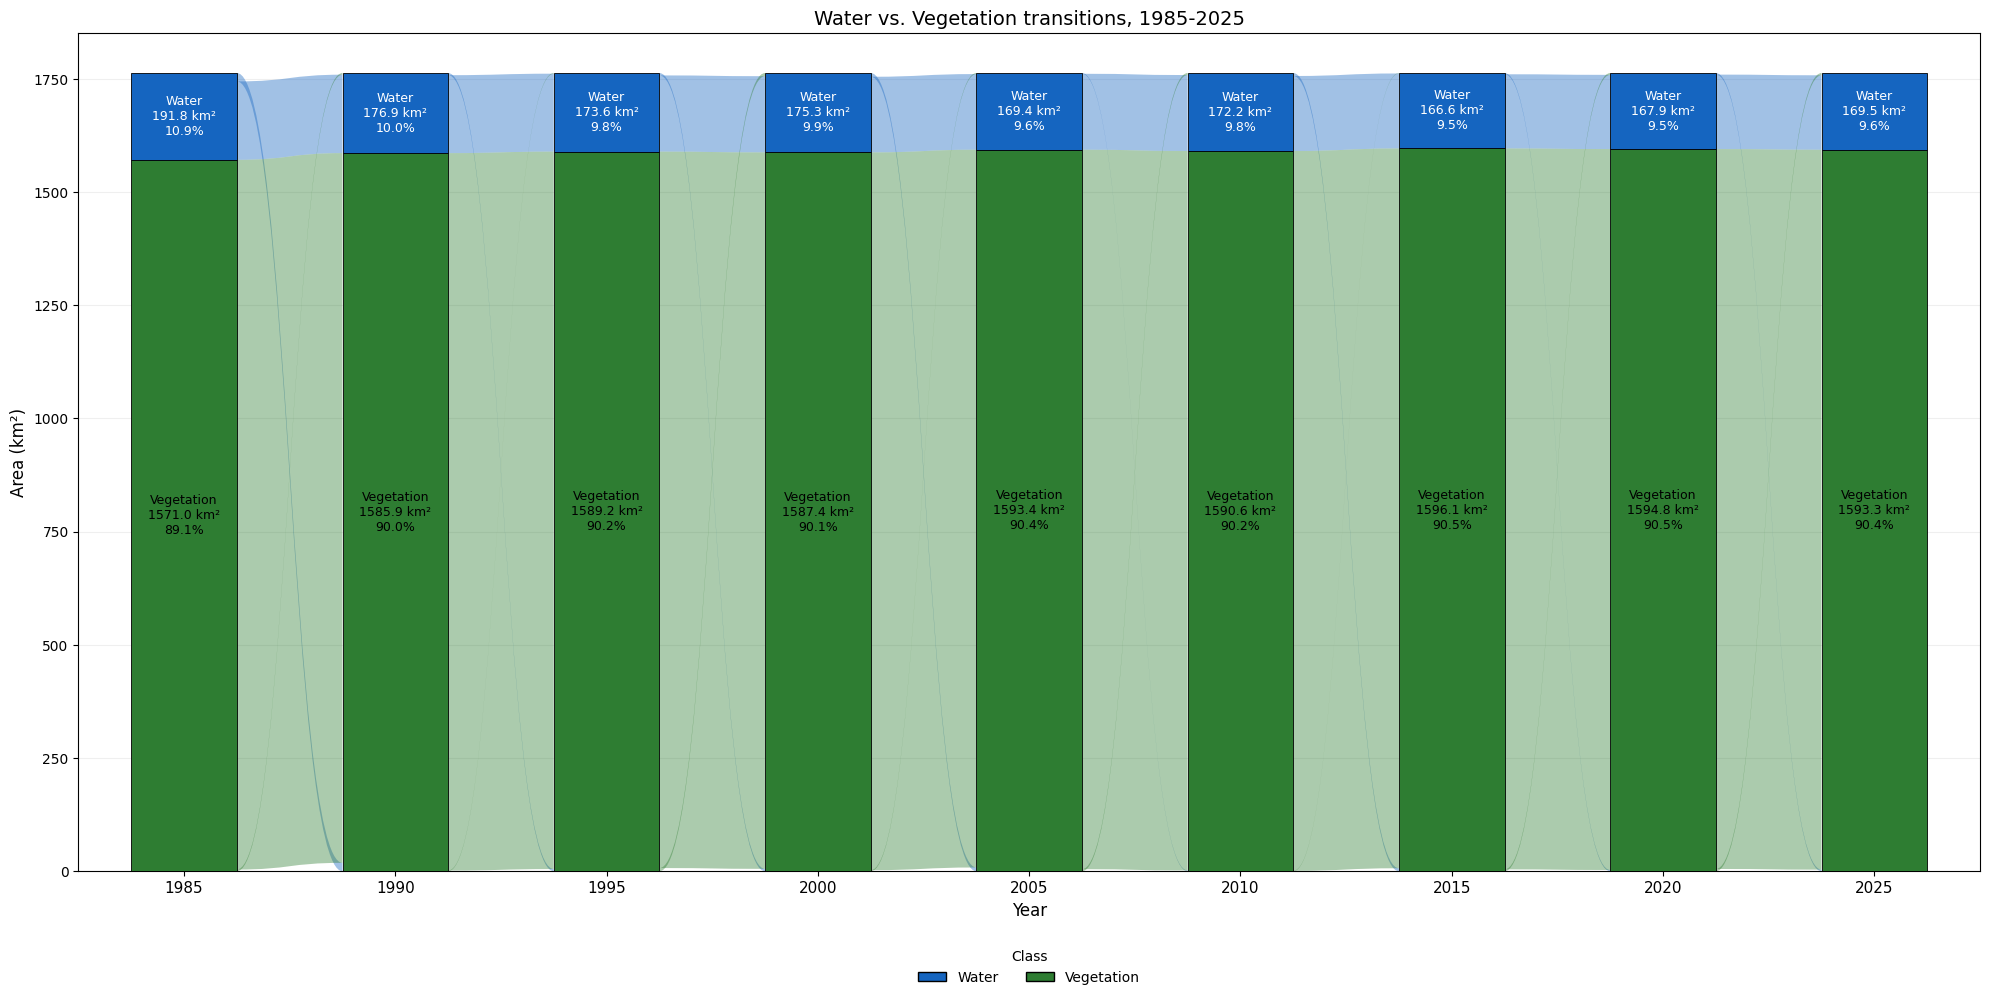

In [44]:
# ============================================
# Alluvial diagram — corrected data, km²
# ============================================

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.path import Path
import matplotlib.patches as mpatches

class_colors = ['#1565C0', '#2E7D32']  # 0=Water (blue), 1=Vegetation (green)

fig, ax = plt.subplots(figsize=(20, 10))
bar_width = 0.5
x_positions = np.arange(len(ALL_YEARS))

stack_order = [1, 0]
stratum_bounds = {}

for i, xc in enumerate(x_positions):
    y_cursor = 0.0
    for c in stack_order:
        h = totals[i, c]
        if h > 0:
            ax.add_patch(Rectangle(
                (xc - bar_width / 2, y_cursor), bar_width, h,
                facecolor=class_colors[c], edgecolor='black', linewidth=0.6, zorder=3
            ))
            pct = 100 * h / totals[i].sum()
            text_color = 'white' if c == 0 else 'black'
            ax.text(xc, y_cursor + h / 2,
                    f'{CLASS_NAMES[c]}\n{h:.1f} km\u00b2\n{pct:.1f}%',
                    ha='center', va='center', fontsize=9, color=text_color, zorder=4)
            stratum_bounds[(i, c)] = (y_cursor, y_cursor + h)
        else:
            stratum_bounds[(i, c)] = (y_cursor, y_cursor)
        y_cursor += h

for i, T in enumerate(transitions):
    x_a = x_positions[i] + bar_width / 2
    x_b = x_positions[i + 1] - bar_width / 2
    src_cursor = {c: stratum_bounds[(i, c)][0] for c in range(n_classes)}
    tgt_cursor = {c: stratum_bounds[(i + 1, c)][0] for c in range(n_classes)}

    for c_from in stack_order[::-1]:
        for c_to in stack_order[::-1]:
            h = T[c_from, c_to]
            if h <= 0:
                continue
            y0_a = src_cursor[c_from]; y1_a = y0_a + h; src_cursor[c_from] = y1_a
            y0_b = tgt_cursor[c_to]; y1_b = y0_b + h; tgt_cursor[c_to] = y1_b
            xm = (x_a + x_b) / 2
            verts = [(x_a, y0_a), (xm, y0_a), (xm, y0_b), (x_b, y0_b),
                     (x_b, y1_b), (xm, y1_b), (xm, y1_a), (x_a, y1_a), (x_a, y0_a)]
            codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4,
                     Path.LINETO, Path.CURVE4, Path.CURVE4, Path.CURVE4, Path.CLOSEPOLY]
            ax.add_patch(mpatches.PathPatch(Path(verts, codes),
                         facecolor=class_colors[c_from], edgecolor='none', alpha=0.4, zorder=2))

ax.set_xticks(x_positions)
ax.set_xticklabels(ALL_YEARS, fontsize=11)
ax.set_ylabel('Area (km\u00b2)', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.set_title(f'Water vs. Vegetation transitions, {ALL_YEARS[0]}-{ALL_YEARS[-1]}', fontsize=14)
ax.set_ylim(0, totals.sum(axis=1).max() * 1.05)
ax.set_xlim(x_positions[0] - 0.5, x_positions[-1] + 0.5)
ax.grid(axis='y', alpha=0.2, zorder=1)
ax.set_axisbelow(True)

legend_patches = [mpatches.Patch(facecolor=class_colors[c], edgecolor='black', label=CLASS_NAMES[c])
                   for c in range(n_classes)]
ax.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, -0.15),
          ncol=n_classes, frameon=False, title='Class')

plt.tight_layout()
plt.savefig('/content/water_vegetation_alluvial_corrected.png', dpi=200, bbox_inches='tight')
plt.show()